In [1]:
import sys
import gc

sys.path.append("../..")  # Adds higher directory to python modules path.

from src import IOFunctions
from src import CalibrationFunctions

IO = IOFunctions.IO_Functions()

from src import MaskFunctions

Mask = MaskFunctions.Mask_Functions()

from src import PlottingBase
import pandas as pd

import os
import matplotlib.pyplot as plt
import numpy as np

plotter = PlottingBase.PublicationPlotter()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from scipy.stats import median_abs_deviation
from scipy.interpolate import interp1d

In [2]:
directories_hole = ['/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughhole_20260415/', '/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughhole_20260416/']

In [3]:
directories_filter = ['/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughfilters_20260415/',
                          '/media/jbeckwith/JSB_BACKUP_01/powermeter_calibration_data_throughfilters_20260416_5nm/']

In [4]:
wavelength_hole = {}
power_meter_hole = {}
wavelength_filter = {}
power_meter_filter = {}

In [5]:
for i, directory in enumerate(directories_hole):
    signal_files = H_F.file_search(directory, 'signal.csv', '')
    background_files = H_F.file_search(directory, 'background.csv', '')
    wavelength_spacing = int(500/(len(signal_files)-1))
    wavelength_hole[i] = np.arange(400, 900+wavelength_spacing, wavelength_spacing)
    power_meter_hole[i] = np.zeros([2, len(signal_files)])
    for j in np.arange(len(signal_files)):
        signal = np.median(pd.read_csv(signal_files[j]).power_W)
        signal_err = median_abs_deviation(pd.read_csv(signal_files[j]).power_W)
        background = np.median(pd.read_csv(background_files[j]).power_W)
        background_err = median_abs_deviation(pd.read_csv(background_files[j]).power_W)
        power_meter_hole[i][0, j] = signal - background
        power_meter_hole[i][1, j] = np.sqrt(np.square(signal_err) + np.square(background_err))

In [6]:
for i, directory in enumerate(directories_filter):
    signal_files = H_F.file_search(directory, 'signal.csv', '')
    background_files = H_F.file_search(directory, 'background.csv', '')
    wavelength_spacing = int(500/(len(signal_files)-1))
    wavelength_filter[i] = np.arange(400, 900+wavelength_spacing, wavelength_spacing)
    power_meter_filter[i] = np.zeros([2, len(signal_files)])
    for j in np.arange(len(signal_files)):
        signal = np.median(pd.read_csv(signal_files[j]).power_W)
        signal_err = median_abs_deviation(pd.read_csv(signal_files[j]).power_W)
        background = np.median(pd.read_csv(background_files[j]).power_W)
        background_err = median_abs_deviation(pd.read_csv(background_files[j]).power_W)
        power_meter_filter[i][0, j] = signal - background
        power_meter_filter[i][1, j] = np.sqrt(np.square(signal_err) + np.square(background_err))

(400.0, 900.0)

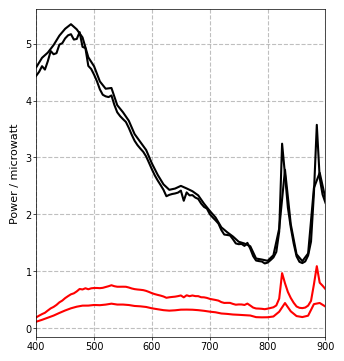

In [7]:
fig, axs = plotter.one_column_plot()

for i in np.arange(len(directories_hole)):
    axs.errorbar(wavelength_hole[i], power_meter_hole[i][0, :]*1e6, yerr=power_meter_hole[i][1, :], color='k')

for i in np.arange(len(directories_filter)):
    axs.errorbar(wavelength_filter[i], power_meter_filter[i][0, :]*1e6, yerr=power_meter_filter[i][1, :], color='red')


axs.set_ylabel('Power / microwatt')
axs.grid(True, ls='--', alpha=0.5, color='gray')
axs.set_xlim([400, 900])

In [8]:
power_calibration = power_meter_filter[0][0,:]/power_meter_hole[0][0,:]

(400.0, 900.0)

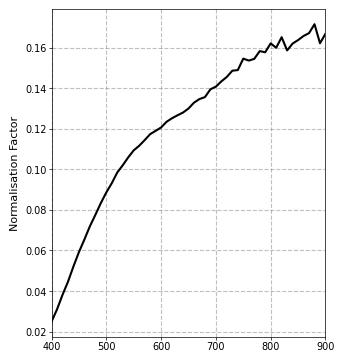

In [9]:
fig, axs = plotter.one_column_plot()

axs.plot(wavelength_filter[0], power_calibration, 'k')

axs.set_ylabel('Normalisation Factor')
axs.grid(True, ls='--', alpha=0.5, color='gray')
axs.set_xlim([400, 900])

## Per-pixel QE calibration

Use the 100-frame monochromatic stacks (400–900 nm, 10 nm steps) and the power-meter readings to compute a per-pixel relative QE map at each wavelength.

**Method:**
1. Load camera calibration (offset, gain, variance) — *do not apply rqe flat-field*
2. For each wavelength: sigma-clip outlier frames using the calibrated noise model, then estimate μ_e per pixel via the constrained MLE (quadratic combining sample mean + variance with known σ_r²)
3. Normalise by the power-meter photon flux Φ(λ) = P(λ)·λ/(h·c) to remove source spectral variation
4. Divide by global maximum → relative QE ∈ [0, 1] per pixel per wavelength
5. Save as `Camera_Calibrations/ZWO_Camera/QE_per_pixel.tif` (51 frames × 2160 × 3840)

In [10]:
calib_dir = "../../Camera_Calibrations/ZWO_Camera"
offset   = IO.read_tiff(os.path.join(calib_dir, "offset.tif"))    # (H, W) ADU
gain     = IO.read_tiff(os.path.join(calib_dir, "gain.tif"))      # ADU / e⁻
variance = IO.read_tiff(os.path.join(calib_dir, "variance.tif"))  # ADU² dark read-noise
# rqe deliberately NOT loaded: it would suppress the per-pixel QE variation we want to measure

mosaic_unit = np.array([["R", "G"], ["G", "B"]])
masks = Mask.get_masks(
    mosaic_unit=mosaic_unit, size_x=offset.shape[0], size_y=offset.shape[1]
)

print(f"offset  : {offset.shape}  mean={offset.mean():.2f} ADU")
print(f"gain    : {gain.shape}   mean={gain.mean():.4f} ADU/e⁻")
print(f"variance: {variance.shape}  mean={variance.mean():.4f} ADU²")
print(f"σ_r     : {(np.sqrt(variance)/gain).mean():.3f} e⁻  (mean read noise)")

offset  : (2160, 3840)  mean=242.58 ADU
gain    : (2160, 3840)   mean=3.6111 ADU/e⁻
variance: (2160, 3840)  mean=9.8906 ADU²
σ_r     : 0.814 e⁻  (mean read noise)


In [11]:
qe_data_dir = '/media/jbeckwith/JSB_BACKUP_01/calibration_data_500frames_20260415/'
wavelengths_nm = np.arange(400, 910, 10)

In [12]:
import glob as _glob

# ── Power-meter readings from the image directories ────────────────────────────
# Each wavelength subdirectory (e.g. 400.0nm/) should contain power-meter CSVs
# with a 'power_W' column, named so that a sorted glob gives them in
# chronological order, e.g.:
#   signal_before.csv / background_before.csv   (taken before the image stack)
#   signal_after.csv  / background_after.csv    (taken after  the image stack)
# Any consistent naming with the same count of signal and background files works.
# The net power from each reading is averaged; a drift warning is raised if the
# first and last readings differ by more than FLAG_THRESH (fractional).

FLAG_THRESH = 0.05   # 5 % fractional drift triggers a warning

power_meter_raw     = np.zeros(len(wavelengths_nm))
power_meter_raw_err = np.zeros(len(wavelengths_nm))
_drift_flags        = []

for _idx, _wl in enumerate(wavelengths_nm):
    _wl_dir   = os.path.join(qe_data_dir, f"{_wl:.1f}nm")
    _sig_files = sorted(_glob.glob(os.path.join(_wl_dir, "signal*.csv")))
    _bg_files  = sorted(_glob.glob(os.path.join(_wl_dir, "background*.csv")))

    if len(_sig_files) == 0:
        raise FileNotFoundError(
            f"No signal*.csv found in {_wl_dir}.\n"
            "Expected files such as signal_before.csv and signal_after.csv."
        )
    if len(_sig_files) != len(_bg_files):
        raise ValueError(
            f"{_wl:.1f} nm: {len(_sig_files)} signal file(s) but "
            f"{len(_bg_files)} background file(s) — counts must match."
        )

    # Net power (signal − background) and its uncertainty for each reading
    _net_power = np.zeros(len(_sig_files))
    _net_err   = np.zeros(len(_sig_files))
    for _r, (_sf, _bf) in enumerate(zip(_sig_files, _bg_files)):
        _s = pd.read_csv(_sf).power_W
        _b = pd.read_csv(_bf).power_W
        _net_power[_r] = np.median(_s) - np.median(_b)
        _net_err[_r]   = np.sqrt(median_abs_deviation(_s)**2 +
                                  median_abs_deviation(_b)**2)

    # Average across readings; combined uncertainty = sqrt(Σ σ²) / N
    power_meter_raw[_idx]     = _net_power.mean()
    power_meter_raw_err[_idx] = np.sqrt((_net_err**2).sum()) / len(_net_err)

    # Drift check between first and last reading
    if len(_net_power) >= 2:
        _mean_p = abs(power_meter_raw[_idx])
        _frac   = abs(_net_power[-1] - _net_power[0]) / max(_mean_p, 1e-30)
        if _frac > FLAG_THRESH:
            _drift_flags.append(
                f"  {_wl:.0f} nm : {_frac*100:.1f}% drift  "
                f"({_net_power[0]*1e9:.3f} nW → {_net_power[-1]*1e9:.3f} nW)"
            )

# Interpolate power_calibration onto the image wavelength grid in case the
# through-hole and image acquisitions used different step sizes.
_pc_interp = interp1d(wavelength_hole[0], power_calibration,
                       kind='linear', fill_value='extrapolate')
_pc_at_wl  = _pc_interp(wavelengths_nm)   # filter-transmission factor at each λ

# Corrected power at the sensor: hole-path reading × filter transmission
power_meter     = power_meter_raw     * _pc_at_wl
power_meter_err = power_meter_raw_err * np.abs(_pc_at_wl)

print("Power at sensor after filter correction:")
for _i in range(0, len(wavelengths_nm), 5):
    print(f"  {wavelengths_nm[_i]:.0f} nm : "
          f"{power_meter[_i]*1e6:7.3f} ± {power_meter_err[_i]*1e6:.3f} μW")

if _drift_flags:
    print(f"\n⚠  Drift warnings — {len(_drift_flags)} wavelength(s) exceeded "
          f"{FLAG_THRESH*100:.0f}% between first and last reading:")
    for _msg in _drift_flags:
        print(_msg)
else:
    n_readings = len(sorted(_glob.glob(
        os.path.join(qe_data_dir, f"{wavelengths_nm[0]:.1f}nm", "signal*.csv"))))
    print(f"\nNo drift warnings ({n_readings} reading(s) per wavelength, "
          f"all within {FLAG_THRESH*100:.0f}%).")

Power at sensor after filter correction:
  400 nm :   0.115 ± 0.000 μW
  450 nm :   0.315 ± 0.000 μW
  500 nm :   0.410 ± 0.000 μW
  550 nm :   0.420 ± 0.000 μW
  600 nm :   0.353 ± 0.000 μW
  650 nm :   0.330 ± 0.000 μW
  700 nm :   0.297 ± 0.000 μW
  750 nm :   0.241 ± 0.000 μW
  800 nm :   0.197 ± 0.000 μW
  850 nm :   0.217 ± 0.000 μW
  900 nm :   0.385 ± 0.000 μW

No drift warnings (2 reading(s) per wavelength, all within 5%).


In [13]:
import tempfile

CHUNK_SIZE = 10   # frames per chunk — reduce if RAM is still tight

# ── Memory-mapped intermediate arrays (live on disk, not in RAM) ──────────────
_mm_dir        = tempfile.mkdtemp(prefix="qe_mmap_")
mean_e         = np.memmap(os.path.join(_mm_dir, "mean_e.dat"),
                            dtype=np.float32, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
var_e_expected = np.memmap(os.path.join(_mm_dir, "var_e.dat"),
                            dtype=np.float32, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
pixel_mask     = np.memmap(os.path.join(_mm_dir, "pixel_mask.dat"),
                            dtype=bool, mode='w+',
                            shape=(len(wavelengths_nm), *offset.shape))
pixel_mask[:]  = True   # initialise: all pixels assumed good

SIGMA_CLIP  = 5.0
CHI2_THRESH = 5.0

# Per-pixel read-noise variance in photoelectron units (known from calibration)
sigma_r2 = (variance / gain**2).astype(np.float64)   # (H, W)

for idx, wl_nm in enumerate(wavelengths_nm):
    tiff_path = os.path.join(qe_data_dir, f"{wl_nm:.1f}nm", "frames.tif")
    n_total   = IO.get_n_frames(tiff_path)

    # ── Pass 1: unclipped mean (float64 accumulator) ───────────────────────────
    sum_x = np.zeros(offset.shape, dtype=np.float64)
    for _s in range(0, n_total, CHUNK_SIZE):
        _frames = list(range(_s, min(_s + CHUNK_SIZE, n_total)))
        _raw    = IO.read_tiff(tiff_path, frame=_frames, dtype="float32", memmap=False)
        if _raw.ndim == 2:
            _raw = _raw[np.newaxis]
        sum_x += ((_raw - offset[np.newaxis]) / gain[np.newaxis]).sum(axis=0)
        del _raw
    xbar_init   = (sum_x / n_total).astype(np.float32)
    sigma_frame = np.sqrt(np.clip(sigma_r2 + xbar_init, 1e-6, None)).astype(np.float32)
    del sum_x

    # ── Pass 2: sigma-clipped sums (float64 accumulators) ─────────────────────
    sum_xc          = np.zeros(offset.shape, dtype=np.float64)   # Σ x  (clipped)
    sum_xc2         = np.zeros(offset.shape, dtype=np.float64)   # Σ x² (clipped)
    n_good          = np.zeros(offset.shape, dtype=np.int32)
    n_clipped_total = 0

    for _s in range(0, n_total, CHUNK_SIZE):
        _frames = list(range(_s, min(_s + CHUNK_SIZE, n_total)))
        _raw    = IO.read_tiff(tiff_path, frame=_frames, dtype="float32", memmap=False)
        if _raw.ndim == 2:
            _raw = _raw[np.newaxis]
        _x    = (_raw - offset[np.newaxis]) / gain[np.newaxis]   # (C, H, W)
        _good = np.abs(_x - xbar_init[np.newaxis]) < SIGMA_CLIP * sigma_frame[np.newaxis]
        sum_xc          += (_x * _good).sum(axis=0).astype(np.float64)
        sum_xc2         += (_x**2 * _good).sum(axis=0).astype(np.float64)
        n_good          += _good.sum(axis=0).astype(np.int32)
        n_clipped_total += int((~_good).sum())
        del _raw, _x, _good

    n_good_f = np.maximum(n_good, 1).astype(np.float64)
    xbar     = np.where(n_good > 1, sum_xc / n_good_f, xbar_init).astype(np.float32)

    # Unbiased sample variance via sum-of-squares identity: (Σx² - (Σx)²/n) / (n-1)
    s2 = np.where(
        n_good > 2,
        (sum_xc2 - sum_xc**2 / n_good_f) / np.maximum(n_good - 1, 1),
        sigma_r2 + xbar
    ).astype(np.float32)
    del sum_xc, sum_xc2

    # ── Constrained MLE (quadratic): x_k ~ N(μ, σ_r² + μ) ────────────────────
    _a    = sigma_r2.astype(np.float64)
    _xb   = xbar.astype(np.float64)
    _s2d  = s2.astype(np.float64)
    _B    = 2*_a + 1 - 2*_xb
    _C    = -(2*_a*_xb + _s2d - _a)
    _disc = np.maximum(_B**2 - 8*_C, 0.0)
    mu_e_f = ((-_B + np.sqrt(_disc)) / 4).astype(np.float32)
    del _a, _xb, _s2d, _B, _C, _disc

    # ── Write results to memory-mapped arrays ──────────────────────────────────
    mean_e[idx]         = mu_e_f
    var_e_expected[idx] = ((sigma_r2 + np.maximum(mu_e_f, 0)) / n_good_f).astype(np.float32)

    _expected_var_frame = np.clip(sigma_r2 + xbar, 1e-6, None)
    pixel_mask[idx]     = (s2 / _expected_var_frame) < CHI2_THRESH

    n_bad      = int((~pixel_mask[idx]).sum())
    clip_pct   = 100.0 * n_clipped_total / (n_total * offset.shape[0] * offset.shape[1])
    print(f"  {wl_nm:.0f} nm  G mean = {mu_e_f[masks['G']].mean():.1f} e⁻  "
          f"bad px = {n_bad}  clipped = {clip_pct:.4f}%      ", end="\r")

    del xbar_init, sigma_frame, xbar, s2, mu_e_f, n_good, n_good_f, _expected_var_frame
    mean_e.flush()
    var_e_expected.flush()
    pixel_mask.flush()
    gc.collect()

print("\nDone.")

  900 nm  G mean = 333.2 e⁻  bad px = 0  clipped = 0.0001%      
Done.


In [14]:
import tifffile as _tifffile

h_planck      = 6.626e-34   # J·s
c_light       = 2.998e8     # m/s
wavelengths_m = wavelengths_nm * 1e-9
Phi = power_meter * wavelengths_m / (h_planck * c_light)   # (N,) photons/s ∝ flux

save_dir     = "../../Camera_Calibrations/ZWO_Camera"
qe_save_path = os.path.join(save_dir, "QE_per_pixel.tif")
wl_save_path = os.path.join(save_dir, "QE_per_pixel_wavelengths_nm.npy")

# ── Pass 1: find global R_max without loading the full (N, H, W) array ────────
R_max = 0.0
for _idx in range(len(wavelengths_nm)):
    _mu   = np.array(mean_e[_idx], dtype=np.float64)   # copy one slice from memmap
    _good = pixel_mask[_idx]
    _R_wl = np.where(_good, _mu, np.nan) / Phi[_idx]
    _wl_max = float(np.nanmax(_R_wl))
    if _wl_max > R_max:
        R_max = _wl_max
    del _mu, _R_wl
    gc.collect()

print(f"R_max = {R_max:.4e}")

# ── Pass 2: write QE_rel wavelength-by-wavelength and keep memmap for plots ───
QE_rel = np.memmap(os.path.join(_mm_dir, "QE_rel.dat"),
                   dtype=np.float32, mode='w+',
                   shape=(len(wavelengths_nm), *offset.shape))

with _tifffile.TiffWriter(qe_save_path, bigtiff=True) as _tif_out:
    for _idx in range(len(wavelengths_nm)):
        _mu    = np.array(mean_e[_idx], dtype=np.float64)
        _good  = pixel_mask[_idx]
        _QE_wl = (np.where(_good, _mu, np.nan) / Phi[_idx] / R_max).astype(np.float32)
        QE_rel[_idx] = _QE_wl
        _tif_out.write(_QE_wl, contiguous=True)
        del _mu, _QE_wl
        gc.collect()

QE_rel.flush()
np.save(wl_save_path, wavelengths_nm)

print(f"Saved  : {qe_save_path}")
print(f"  Shape: ({len(wavelengths_nm)}, {offset.shape[0]}, {offset.shape[1]})")
print(f"  R_max: {R_max:.4e}")
print(f"  λ range: {wavelengths_nm[0]}–{wavelengths_nm[-1]} nm  "
      f"(step {int(wavelengths_nm[1]-wavelengths_nm[0])} nm)")
print(f"  NaN pixels (bad): {int(np.isnan(QE_rel).sum())} / {QE_rel.size}")

R_max = 2.6315e-09
Saved  : ../../Camera_Calibrations/ZWO_Camera/QE_per_pixel.tif
  Shape: (51, 2160, 3840)
  R_max: 2.6315e-09
  λ range: 400–900 nm  (step 10 nm)
  NaN pixels (bad): 3 / 423014400


/tmp/ipykernel_15151/675281771.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


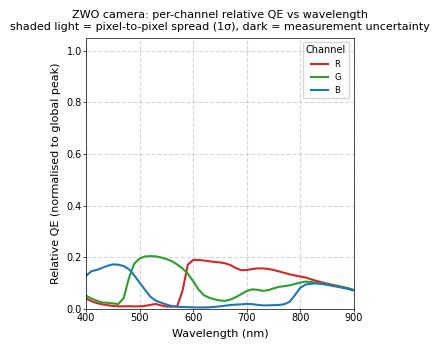

In [19]:
channel_colours = {"R": "tab:red", "G": "tab:green", "B": "tab:blue"}

qe_mean = {}
qe_std  = {}
qe_unc  = {}

rel_pm = power_meter_err / np.where(power_meter > 0, power_meter, np.nan)  # (51,)

for ch in channel_colours:
    m = masks[ch]  # (H, W) boolean

    means = np.zeros(len(wavelengths_nm))
    stds  = np.zeros(len(wavelengths_nm))
    uncs  = np.zeros(len(wavelengths_nm))

    for idx in range(len(wavelengths_nm)):
        good = m & pixel_mask[idx]                     # good pixels in this channel

        vals = QE_rel[idx][good].astype(np.float64)
        w    = 1.0 / np.clip(var_e_expected[idx][good].astype(np.float64), 1e-30, None)

        w_sum      = w.sum()
        mu_w       = (w * vals).sum() / w_sum
        means[idx] = mu_w
        stds[idx]  = np.sqrt((w * (vals - mu_w)**2).sum() / w_sum)  # weighted spatial std

        # Uncertainty of the weighted mean (measurement precision)
        meas_unc   = np.sqrt(1.0 / w_sum) / R_max
        uncs[idx]  = np.sqrt(meas_unc**2 + (mu_w * rel_pm[idx])**2)

    qe_mean[ch] = means
    qe_std[ch]  = stds
    qe_unc[ch]  = uncs

fig, ax = plotter.one_column_plot()
for ch, colour in channel_colours.items():
    ax.plot(wavelengths_nm, qe_mean[ch], color=colour, lw=1.5, label=ch)
    #ax.fill_between(
    #    wavelengths_nm,
    #    qe_mean[ch] - qe_std[ch],
    #    qe_mean[ch] + qe_std[ch],
    #    color=colour, alpha=0.2
    #)
    #ax.fill_between(
    #    wavelengths_nm,
    #    qe_mean[ch] - qe_unc[ch],
    #    qe_mean[ch] + qe_unc[ch],
    #    color=colour, alpha=0.4
    #)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Relative QE (normalised to global peak)")
ax.set_ylim(0, 1.05)
ax.set_xlim(400, 900)
ax.legend(title="Channel")
ax.grid(True, ls='--', alpha=0.5)
ax.set_title("ZWO camera: per-channel relative QE vs wavelength\n"
             "shaded light = pixel-to-pixel spread (1σ), dark = measurement uncertainty")
plt.tight_layout()
plt.show()

In [20]:
qe_std

{'R': array([0.00204266, 0.0015309 , 0.00115472, 0.00090748, 0.00074237,
        0.00060424, 0.00052255, 0.00051975, 0.00054563, 0.00051229,
        0.00052242, 0.00059341, 0.00080566, 0.00097223, 0.00069385,
        0.00048913, 0.0004658 , 0.00054297, 0.00332247, 0.00807251,
        0.00890854, 0.00890779, 0.00881814, 0.00868319, 0.00854863,
        0.0084609 , 0.0082828 , 0.00796401, 0.0074322 , 0.00708139,
        0.00713426, 0.00735664, 0.00745789, 0.00744219, 0.00737092,
        0.00720683, 0.00699645, 0.00675378, 0.00651386, 0.006258  ,
        0.0060341 , 0.00585211, 0.00554427, 0.00532153, 0.0051001 ,
        0.0047972 , 0.0045514 , 0.00434059, 0.00410668, 0.00389246,
        0.00357435]),
 'G': array([0.00260647, 0.00203584, 0.00163542, 0.00127556, 0.00124177,
        0.00112275, 0.0010134 , 0.00218401, 0.00585522, 0.008419  ,
        0.00938164, 0.00970984, 0.00978668, 0.00973179, 0.00952695,
        0.00924194, 0.00885468, 0.00826172, 0.00752325, 0.00657548,
        0.005224

/tmp/ipykernel_15151/4076581844.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


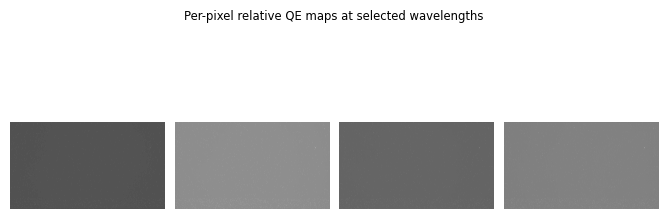

In [22]:
select_wl_nm = [450, 530, 620, 700]

fig, axs = plotter.two_column_plot(ncols=len(select_wl_nm))
for ax, wl in zip(axs, select_wl_nm):
    idx = int(np.where(wavelengths_nm == wl)[0][0])
    qe_map = QE_rel[idx].copy()
    vmax = float(np.nanpercentile(qe_map, 99.5))
    ax = plotter.image_plot(
        ax, qe_map,
        scalebarlabel="", scalebarsize=0, colorbar=False,
        vmin=0, vmax=vmax
    )

fig.suptitle("Per-pixel relative QE maps at selected wavelengths")
plt.tight_layout()
plt.show()